In [ ]:
# !pip install bitsandbytes evaluate

In [ ]:
from huggingface_hub import login

HF_TOKEN = "..." # replace with your own HuggingFace Token

if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("Token is not set. Please set your HF_TOKEN.")

Successfully logged in to Hugging Face!


In [ ]:
import json
import hashlib
import random
import os
import torch.nn as nn
import pandas as pd
import functools
import numpy as np
import torch
import shutil
import evaluate
import math
import gc, sys
from tqdm import tqdm
from collections import defaultdict
from datasets import load_from_disk
from dataclasses import dataclass
import torch.nn.functional as F
from torch.nn.functional import softmax
from torch.utils.data import DataLoader
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, AutoModelForSequenceClassification, TrainerCallback, TrainerControl, TrainerState, Trainer, BitsAndBytesConfig, DataCollatorWithPadding, AutoConfig, PreTrainedTokenizerBase
from transformers.trainer_utils import IntervalStrategy
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model, PeftModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [ ]:
with open("challenge_data.json", "r") as f:
    data = json.load(f)

texts = [item["conversation_text"].strip() for item in data]
intents = [item["intent"] for item in data]

le = LabelEncoder()
int_labels = le.fit_transform(intents)

label_names = le.classes_.tolist()
label_path = "label_names.json"
with open(label_path, "w") as f:
    json.dump(label_names, f, indent=2)

x_train, x_val, y_train, y_val = train_test_split(
    texts, int_labels, test_size=0.1, stratify=int_labels, random_state=42
)

ds = DatasetDict({
    "train": Dataset.from_dict({"text": x_train, "labels": y_train}),
    "val": Dataset.from_dict({"text": x_val, "labels": y_val}),
})

print(ds)
print(ds["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 1012
    })
    val: Dataset({
        features: ['text', 'labels'],
        num_rows: 113
    })
})
{'text': "Bot: Hi there, this is [Bank Name] calling about your account. We noticed that your payment for March 15th is past due.\n\nUser: Ugh, great. Another bill collector calling. Look, I don't have the money right now. My mom just got really sick and I'm her primary caregiver now. I don't know how I'm going to pay for her medical bills, let alone my credit card.\n\nBot: I'm so sorry to hear that, ma'am. We want to help you get back on track with your payments. Can you tell me a bit more about your situation and how long you think it'll take you to get back to paying your bills regularly?\n\nUser: It's just... I don't know. I'm trying to figure it out as I go. But I was hoping maybe we could push the due date back to June 15th? That way I can get some more money together and make a plan to pay 

In [ ]:
model_name = 'mistralai/Mistral-7B-v0.1'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

texts = ds["train"]["text"][:] + ds["val"]["text"][:]

lengths = [len(tokenizer(text, truncation=False, add_special_tokens=True)["input_ids"]) for text in texts]

print(f"Max length: {max(lengths)}")
print(f"Mean length: {np.mean(lengths):.2f}")
print(f"Median length: {np.median(lengths)}")
print(f"95th percentile: {np.percentile(lengths, 95)}")
print(f"99th percentile: {np.percentile(lengths, 99)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Max length: 699
Mean length: 400.76
Median length: 398.0
95th percentile: 528.0
99th percentile: 584.52


In [ ]:
def tokenize_examples(examples, tokenizer):
    tokenized = tokenizer(examples['text'], truncation=True, padding="max_length", max_length=1024)
    tokenized['labels'] = examples['labels']
    return tokenized

tokenized_ds = ds.map(functools.partial(tokenize_examples, tokenizer=tokenizer), batched=True)
tokenized_ds = tokenized_ds.with_format('torch')

Map:   0%|          | 0/1012 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

In [ ]:
# qunatization config
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16
)

# lora config
lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.1,
    bias='none',
    task_type='SEQ_CLS'
)

# load model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    num_labels=len(label_names)
)
model = prepare_model_for_kbit_training(model)
model = get_peft_model(model, lora_config)
model.config.pad_token_id = tokenizer.pad_token_id

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.1k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of MistralForSequenceClassification were not initialized from the model checkpoint at mistralai/Mistral-7B-v0.1 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def collate_fn(batch, tokenizer):
    input_ids = [item['input_ids'] for item in batch]
    attention_mask = [item['attention_mask'] for item in batch]
    labels = torch.tensor([item['labels'] for item in batch], dtype=torch.long)

    input_ids = torch.nn.utils.rnn.pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = torch.nn.utils.rnn.pad_sequence(attention_mask, batch_first=True, padding_value=0)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(p):
    preds = torch.argmax(torch.tensor(p.predictions), dim=1).numpy()
    labels = p.label_ids
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_micro": f1_score(labels, preds, average="micro"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [ ]:
class LoggingCallback(TrainerCallback):
    def __init__(self):
        self.logs = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            entry = {"step": state.global_step}
            entry.update({k: v for k, v in logs.items()})
            self.logs.append(entry)
            print(f"Step {state.global_step} | Logs: {logs}")

training_args = TrainingArguments(
    output_dir="intent_classification",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    optim="paged_adamw_32bit",
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=5,
    max_grad_norm=1.0,
    warmup_ratio=0.1,
    group_by_length=True,
    lr_scheduler_type="linear",
    report_to="none",
    disable_tqdm=False,
    bf16=True,
    save_total_limit=2,
    learning_rate = 2e-5,
    per_device_eval_batch_size = 8,
    weight_decay = 0.01
)

logging_callback = LoggingCallback()

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized_ds["train"],
    eval_dataset = tokenized_ds["val"],
    tokenizer = tokenizer,
    data_collator = functools.partial(collate_fn, tokenizer=tokenizer),
    compute_metrics = compute_metrics,
    callbacks=[logging_callback]
)

/tmp/ipython-input-601804192.py:37: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro
1,1.601800,0.863785,0.752212,0.752212,0.745867
2,0.054400,0.245941,0.920354,0.920354,0.922055
3,0.000100,0.181448,0.973451,0.973451,0.973605


Step 5 | Logs: {'loss': 19.911, 'grad_norm': 475.210205078125, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.07874015748031496}
Step 10 | Logs: {'loss': 15.3861, 'grad_norm': 416.6495361328125, 'learning_rate': 9e-06, 'epoch': 0.15748031496062992}
Step 15 | Logs: {'loss': 13.0861, 'grad_norm': 452.2761535644531, 'learning_rate': 1.4e-05, 'epoch': 0.23622047244094488}
Step 20 | Logs: {'loss': 10.0307, 'grad_norm': 283.1590576171875, 'learning_rate': 1.9e-05, 'epoch': 0.31496062992125984}
Step 25 | Logs: {'loss': 7.835, 'grad_norm': 445.839599609375, 'learning_rate': 1.9534883720930235e-05, 'epoch': 0.3937007874015748}
Step 30 | Logs: {'loss': 6.8235, 'grad_norm': 293.34405517578125, 'learning_rate': 1.8953488372093027e-05, 'epoch': 0.47244094488188976}
Step 35 | Logs: {'loss': 6.163, 'grad_norm': 305.4235534667969, 'learning_rate': 1.8372093023255815e-05, 'epoch': 0.5511811023622047}
Step 40 | Logs: {'loss': 5.5401, 'grad_norm': 266.5826416015625, 'learning_rate': 1.779069767441860

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step 65 | Logs: {'loss': 1.8065, 'grad_norm': 90.93067932128906, 'learning_rate': 1.488372093023256e-05, 'epoch': 1.015748031496063}
Step 70 | Logs: {'loss': 0.8019, 'grad_norm': 120.40974426269531, 'learning_rate': 1.4302325581395352e-05, 'epoch': 1.094488188976378}
Step 75 | Logs: {'loss': 0.5029, 'grad_norm': 150.31484985351562, 'learning_rate': 1.372093023255814e-05, 'epoch': 1.1732283464566928}
Step 80 | Logs: {'loss': 0.1724, 'grad_norm': 40.523014068603516, 'learning_rate': 1.313953488372093e-05, 'epoch': 1.2519685039370079}
Step 85 | Logs: {'loss': 0.1986, 'grad_norm': 19.598834991455078, 'learning_rate': 1.2558139534883723e-05, 'epoch': 1.330708661417323}
Step 90 | Logs: {'loss': 0.3718, 'grad_norm': 9.059989929199219, 'learning_rate': 1.1976744186046511e-05, 'epoch': 1.4094488188976377}
Step 95 | Logs: {'loss': 0.2762, 'grad_norm': 71.24850463867188, 'learning_rate': 1.1395348837209304e-05, 'epoch': 1.4881889763779528}
Step 100 | Logs: {'loss': 0.2731, 'grad_norm': 0.11409486

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:929: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step 130 | Logs: {'loss': 0.597, 'grad_norm': 0.2800031006336212, 'learning_rate': 7.325581395348837e-06, 'epoch': 2.031496062992126}
Step 135 | Logs: {'loss': 0.0025, 'grad_norm': 0.11226113885641098, 'learning_rate': 6.744186046511628e-06, 'epoch': 2.1102362204724407}
Step 140 | Logs: {'loss': 0.0423, 'grad_norm': 0.11815784126520157, 'learning_rate': 6.162790697674419e-06, 'epoch': 2.188976377952756}
Step 145 | Logs: {'loss': 0.0004, 'grad_norm': 0.012687069363892078, 'learning_rate': 5.58139534883721e-06, 'epoch': 2.267716535433071}
Step 150 | Logs: {'loss': 0.0234, 'grad_norm': 0.04909543693065643, 'learning_rate': 5e-06, 'epoch': 2.3464566929133857}
Step 155 | Logs: {'loss': 0.0332, 'grad_norm': 0.006016826722770929, 'learning_rate': 4.418604651162791e-06, 'epoch': 2.425196850393701}
Step 160 | Logs: {'loss': 0.0002, 'grad_norm': 0.034108374267816544, 'learning_rate': 3.837209302325582e-06, 'epoch': 2.5039370078740157}
Step 165 | Logs: {'loss': 0.0006, 'grad_norm': 1.820789575576

TrainOutput(global_step=192, training_loss=2.633212653687224, metrics={'train_runtime': 1521.8091, 'train_samples_per_second': 1.995, 'train_steps_per_second': 0.126, 'total_flos': 1.3175765874612634e+17, 'train_loss': 2.633212653687224, 'epoch': 3.0})

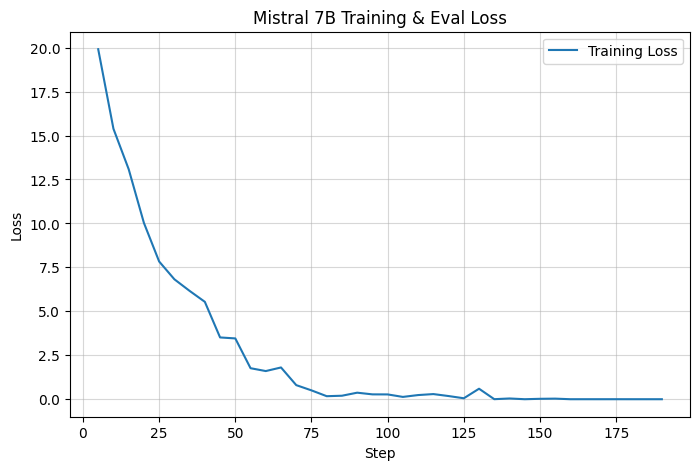

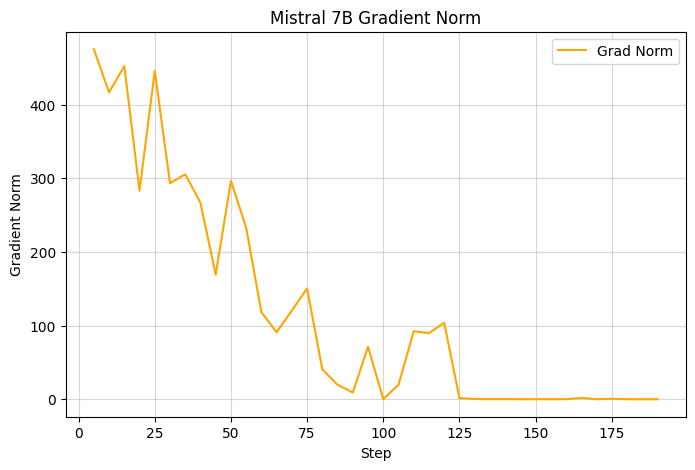

In [ ]:
log_df = pd.DataFrame(logging_callback.logs)

train_df = log_df[log_df["loss"].notna()]

plt.figure(figsize=(8,5))
plt.plot(train_df["step"], train_df["loss"], label="Training Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Mistral 7B Training & Eval Loss")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

if "grad_norm" in log_df:
    grad_df = log_df[log_df["grad_norm"].notna()]
    plt.figure(figsize=(8,5))
    plt.plot(grad_df["step"], grad_df["grad_norm"], color="orange", label="Grad Norm")
    plt.xlabel("Step")
    plt.ylabel("Gradient Norm")
    plt.title("Mistral 7B Gradient Norm")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()


Fine-Tuned Mistral 7B 4bit Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        12
           1     1.0000    0.9167    0.9565        12
           2     0.9286    1.0000    0.9630        13
           3     1.0000    1.0000    1.0000        13
           4     1.0000    0.9231    0.9600        13
           5     0.9231    1.0000    0.9600        12
           6     1.0000    0.9231    0.9600        13
           7     1.0000    1.0000    1.0000        12
           8     0.9286    1.0000    0.9630        13

    accuracy                         0.9735       113
   macro avg     0.9756    0.9736    0.9736       113
weighted avg     0.9754    0.9735    0.9734       113



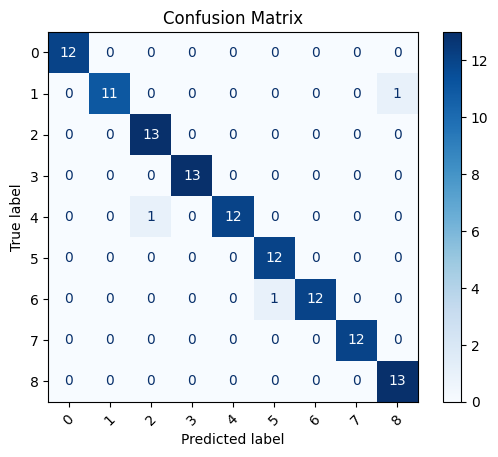

In [ ]:
predictions = trainer.predict(tokenized_ds["val"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=-1)

print("Fine-Tuned Mistral 7B 4bit Classification Report:\n")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
